In [51]:
import os
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from typing import Annotated, TypedDict,Literal,List
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [52]:
load_dotenv()

True

In [53]:
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [54]:
class chatState(TypedDict):
    messages:Annotated[List[BaseMessage],add_messages]

In [55]:
checkpoint=MemorySaver()
graph=StateGraph(chatState)


In [ ]:
def chat_fun(state:chatState)->chatState:
    messages=state["messages"]
    response=llm.invoke(messages)
    return {'messages':[response]}

In [57]:
graph.add_node("ChatBot",chat_fun)
graph.add_edge(START,"ChatBot")
graph.add_edge("ChatBot",END)

In [58]:
workflow=graph.compile(checkpointer=checkpoint)

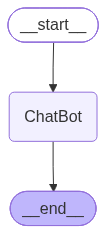

In [59]:
workflow

In [60]:
thread_id='1'
while True:
    input_text=input(" ")
    print(f"User: {input_text}")
    if input_text.lower() in ["exit","quit"]:
        break
    config={'configurable':{"thread_id":thread_id}}
    reponse=workflow.invoke({"messages":[HumanMessage(content=input_text)]},config=config)
    print(f"Bot: {reponse['messages'][-1].content}")



User: hello
content='Hello. How can I assist you today?' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.010854642, 'completion_tokens_details': None, 'prompt_time': 0.001699309, 'prompt_tokens_details': None, 'queue_time': 0.05145994, 'total_time': 0.012553951}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019fbe6c-518c-7452-addc-e0e7a22d5abf-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46}
Bot: Hello. How can I assist you today?
User: exit


In [61]:
workflow.get_state(config={'configurable':{"thread_id":thread_id}})

StateSnapshot(values={'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='27dd17e6-427b-441a-92a3-eae5ec970dbb'), AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.010854642, 'completion_tokens_details': None, 'prompt_time': 0.001699309, 'prompt_tokens_details': None, 'queue_time': 0.05145994, 'total_time': 0.012553951}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fbe6c-518c-7452-addc-e0e7a22d5abf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})]}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd07-ad06-6012-8001-3a478125185c'}}, metadata